In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device="mps",
    workers=0,
    cache=False,
    overlap_mask=False,
    project="yolov8n_coco_bag_seg",
    name="run1",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


SEGMENTATION DATASET EDA

📊 Dataset Overview:
  Train images: 698
  Train labels: 698
  Val images: 198
  Val labels: 198

⚠️ Missing files:
  Train: 0 images without labels
  Train: 0 labels without images

📈 TRAIN Set Statistics:
  Total objects: 5244
  Avg objects per image: 7.51
  Median objects per image: 4.00
  Avg polygon complexity: 37.5 points
  Avg object area ratio: 0.0126 (normalized)
  Empty label files: 0
  Invalid label files: 0
  Class distribution: {0: 5244}

📈 VAL Set Statistics:
  Total objects: 611
  Avg objects per image: 3.09
  Median objects per image: 2.00
  Avg polygon complexity: 37.8 points
  Avg object area ratio: 0.0108 (normalized)
  Empty label files: 0
  Invalid label files: 0
  Class distribution: {0: 611}

🖼️ Image Statistics:
  Avg width: 598.7 px
  Avg height: 451.2 px
  Avg aspect ratio: 1.38
  Avg file size: 156.0 KB
  Channel distribution: Counter({3: 100})


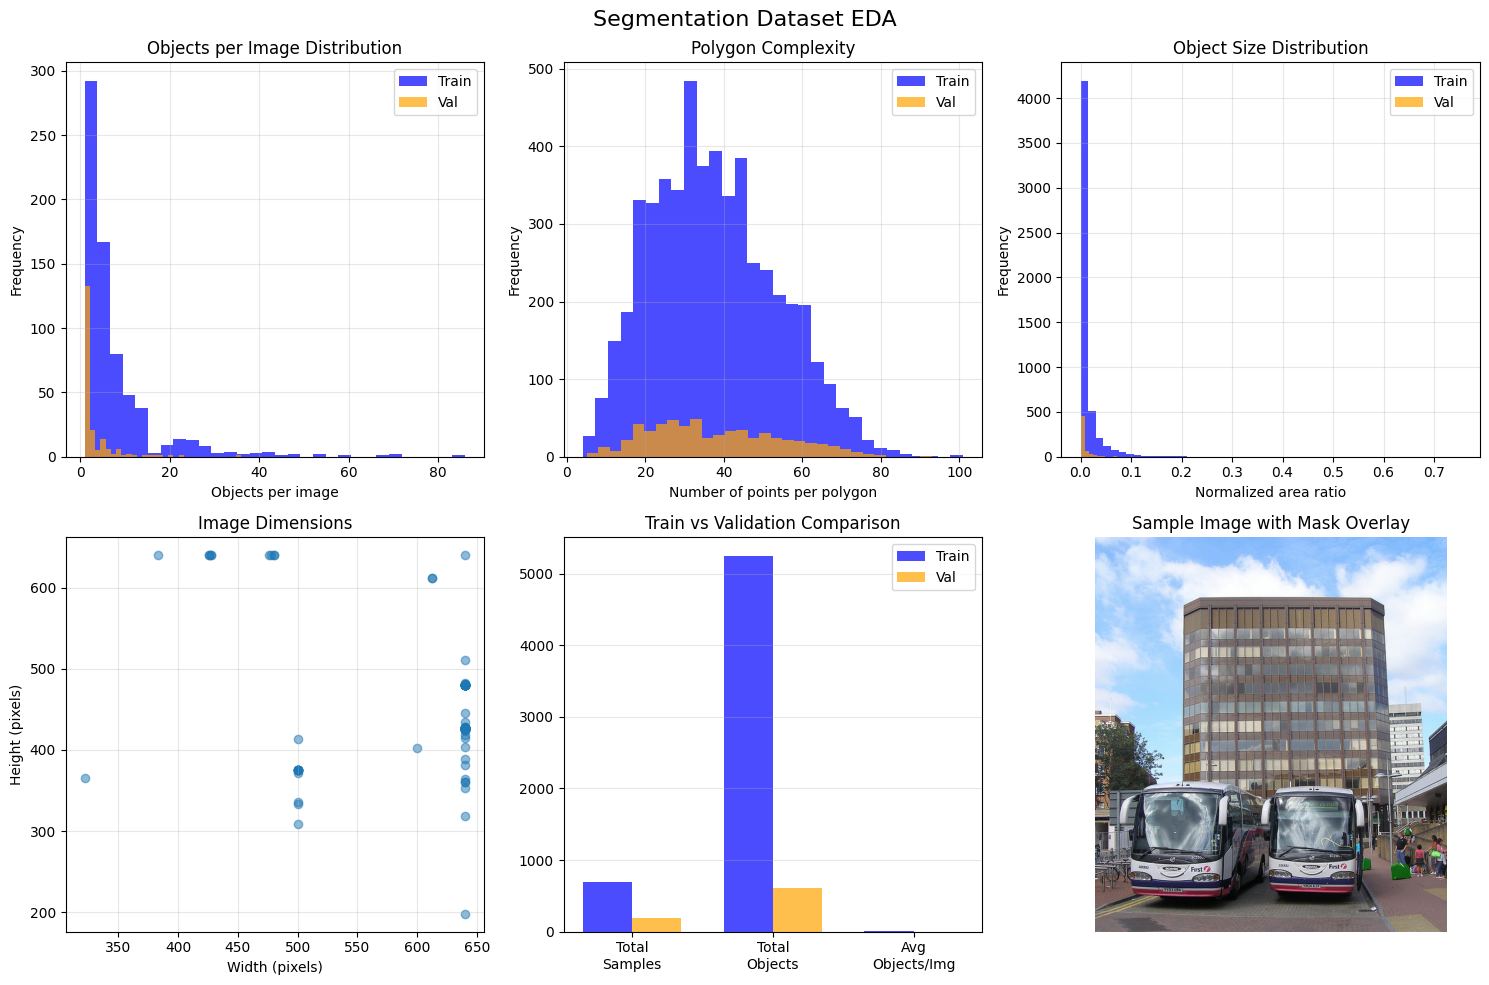


📊 EDA visualization saved to: /Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg/eda_visualization.png

CLASS BALANCE ANALYSIS

Total objects across dataset: 5855

Class distribution:
  bag (ID 0): 5855 objects (100.0%)

📄 EDA report saved to: /Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg/eda_report.txt

✅ EDA complete! Check the generated visualizations and report.


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import pandas as pd
from PIL import Image
import glob
from pathlib import Path

EXPORT_DIR = "/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg"

def analyze_dataset():
    """Comprehensive EDA for segmentation dataset"""
    
    print("="*60)
    print("SEGMENTATION DATASET EDA")
    print("="*60)
    
    # Get all image and label paths
    train_images = glob.glob(os.path.join(EXPORT_DIR, "images/train/*.*"))
    val_images = glob.glob(os.path.join(EXPORT_DIR, "images/val/*.*"))
    train_labels = glob.glob(os.path.join(EXPORT_DIR, "labels/train/*.txt"))
    val_labels = glob.glob(os.path.join(EXPORT_DIR, "labels/val/*.txt"))
    
    print(f"\n📊 Dataset Overview:")
    print(f"  Train images: {len(train_images)}")
    print(f"  Train labels: {len(train_labels)}")
    print(f"  Val images: {len(val_images)}")
    print(f"  Val labels: {len(val_labels)}")
    
    # Check for missing labels
    train_image_stems = set([Path(f).stem for f in train_images])
    train_label_stems = set([Path(f).stem for f in train_labels])
    missing_train_labels = train_image_stems - train_label_stems
    missing_train_images = train_label_stems - train_image_stems
    
    print(f"\n⚠️ Missing files:")
    print(f"  Train: {len(missing_train_labels)} images without labels")
    print(f"  Train: {len(missing_train_images)} labels without images")
    
    # Analyze label files
    train_stats = analyze_labels(train_labels, "train")
    val_stats = analyze_labels(val_labels, "val")
    
    # Analyze images
    image_stats = analyze_images(train_images + val_images)
    
    # Create visualization
    create_visualizations(train_stats, val_stats, image_stats, train_labels, val_labels)
    
    return train_stats, val_stats, image_stats

def analyze_labels(label_paths, split_name):
    """Analyze label files for segmentation polygons"""
    
    stats = {
        "total_samples": len(label_paths),
        "total_objects": 0,
        "objects_per_image": [],
        "polygon_points": [],  # number of points per polygon
        "area_ratios": [],  # area of polygon relative to image
        "class_distribution": defaultdict(int),
        "empty_labels": 0,
        "invalid_labels": 0
    }
    
    for label_path in label_paths:
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            if not lines:
                stats["empty_labels"] += 1
                continue
                
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                    
                parts = line.split()
                if len(parts) < 3:
                    stats["invalid_labels"] += 1
                    continue
                
                # Get class ID (first element)
                class_id = int(parts[0])
                stats["class_distribution"][class_id] += 1
                stats["total_objects"] += 1
                
                # Get polygon points (even number after class_id)
                points = parts[1:]
                if len(points) % 2 == 0 and len(points) >= 6:
                    stats["polygon_points"].append(len(points) // 2)
                
                # Calculate area ratio (rough estimate from normalized coordinates)
                if len(points) >= 6:
                    # Convert normalized coordinates to polygon area
                    coords = [float(p) for p in points]
                    x_coords = coords[0::2]
                    y_coords = coords[1::2]
                    
                    # Shoelace formula for polygon area (in normalized space)
                    area = 0.5 * abs(sum(x_coords[i] * y_coords[(i+1) % len(x_coords)] 
                                        - x_coords[(i+1) % len(x_coords)] * y_coords[i] 
                                        for i in range(len(x_coords))))
                    stats["area_ratios"].append(area)
                
            stats["objects_per_image"].append(len(lines))
            
        except Exception as e:
            print(f"Error reading {label_path}: {e}")
            stats["invalid_labels"] += 1
    
    # Calculate statistics
    stats["avg_objects_per_image"] = np.mean(stats["objects_per_image"]) if stats["objects_per_image"] else 0
    stats["median_objects_per_image"] = np.median(stats["objects_per_image"]) if stats["objects_per_image"] else 0
    stats["avg_polygon_points"] = np.mean(stats["polygon_points"]) if stats["polygon_points"] else 0
    stats["avg_area_ratio"] = np.mean(stats["area_ratios"]) if stats["area_ratios"] else 0
    
    print(f"\n📈 {split_name.upper()} Set Statistics:")
    print(f"  Total objects: {stats['total_objects']}")
    print(f"  Avg objects per image: {stats['avg_objects_per_image']:.2f}")
    print(f"  Median objects per image: {stats['median_objects_per_image']:.2f}")
    print(f"  Avg polygon complexity: {stats['avg_polygon_points']:.1f} points")
    print(f"  Avg object area ratio: {stats['avg_area_ratio']:.4f} (normalized)")
    print(f"  Empty label files: {stats['empty_labels']}")
    print(f"  Invalid label files: {stats['invalid_labels']}")
    
    if stats["class_distribution"]:
        print(f"  Class distribution: {dict(stats['class_distribution'])}")
    
    return stats

def analyze_images(image_paths):
    """Analyze image properties"""
    
    stats = {
        "total_images": len(image_paths),
        "widths": [],
        "heights": [],
        "aspect_ratios": [],
        "channels": [],
        "file_sizes": []
    }
    
    for img_path in image_paths[:100]:  # Sample first 100 images for speed
        try:
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                stats["heights"].append(h)
                stats["widths"].append(w)
                stats["aspect_ratios"].append(w / h)
                stats["channels"].append(img.shape[2] if len(img.shape) > 2 else 1)
                
                # File size
                stats["file_sizes"].append(os.path.getsize(img_path) / 1024)  # KB
        except Exception as e:
            print(f"Error reading {img_path}: {e}")
    
    print(f"\n🖼️ Image Statistics:")
    print(f"  Avg width: {np.mean(stats['widths']):.1f} px")
    print(f"  Avg height: {np.mean(stats['heights']):.1f} px")
    print(f"  Avg aspect ratio: {np.mean(stats['aspect_ratios']):.2f}")
    print(f"  Avg file size: {np.mean(stats['file_sizes']):.1f} KB")
    print(f"  Channel distribution: {Counter(stats['channels'])}")
    
    return stats

def create_visualizations(train_stats, val_stats, image_stats, train_labels, val_labels):
    """Create comprehensive visualizations"""
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("Segmentation Dataset EDA", fontsize=16)
    
    # 1. Objects per image distribution
    ax = axes[0, 0]
    ax.hist(train_stats["objects_per_image"], bins=30, alpha=0.7, label="Train", color='blue')
    ax.hist(val_stats["objects_per_image"], bins=30, alpha=0.7, label="Val", color='orange')
    ax.set_xlabel("Objects per image")
    ax.set_ylabel("Frequency")
    ax.set_title("Objects per Image Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Polygon complexity distribution
    ax = axes[0, 1]
    ax.hist(train_stats["polygon_points"], bins=30, alpha=0.7, label="Train", color='blue')
    ax.hist(val_stats["polygon_points"], bins=30, alpha=0.7, label="Val", color='orange')
    ax.set_xlabel("Number of points per polygon")
    ax.set_ylabel("Frequency")
    ax.set_title("Polygon Complexity")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Object area distribution
    ax = axes[0, 2]
    ax.hist(train_stats["area_ratios"], bins=50, alpha=0.7, label="Train", color='blue')
    ax.hist(val_stats["area_ratios"], bins=50, alpha=0.7, label="Val", color='orange')
    ax.set_xlabel("Normalized area ratio")
    ax.set_ylabel("Frequency")
    ax.set_title("Object Size Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Image dimensions
    ax = axes[1, 0]
    ax.scatter(image_stats["widths"], image_stats["heights"], alpha=0.5)
    ax.set_xlabel("Width (pixels)")
    ax.set_ylabel("Height (pixels)")
    ax.set_title("Image Dimensions")
    ax.grid(True, alpha=0.3)
    
    # 5. Dataset comparison
    ax = axes[1, 1]
    categories = ['Total\nSamples', 'Total\nObjects', 'Avg\nObjects/Img']
    train_vals = [train_stats["total_samples"], train_stats["total_objects"], 
                  train_stats["avg_objects_per_image"]]
    val_vals = [val_stats["total_samples"], val_stats["total_objects"], 
                val_stats["avg_objects_per_image"]]
    
    x = np.arange(len(categories))
    width = 0.35
    ax.bar(x - width/2, train_vals, width, label='Train', color='blue', alpha=0.7)
    ax.bar(x + width/2, val_vals, width, label='Val', color='orange', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_title("Train vs Validation Comparison")
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Sample visualizations
    ax = axes[1, 2]
    visualize_sample_images(train_labels[:3], ax)
    
    plt.tight_layout()
    plt.savefig(os.path.join(EXPORT_DIR, "eda_visualization.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 EDA visualization saved to: {os.path.join(EXPORT_DIR, 'eda_visualization.png')}")

def visualize_sample_images(label_paths, ax):
    """Visualize sample images with their masks"""
    
    if not label_paths:
        ax.text(0.5, 0.5, "No samples available", ha='center', va='center')
        ax.axis('off')
        return
    
    # Get corresponding image path
    sample_label = label_paths[0]
    image_path = sample_label.replace("labels", "images").replace(".txt", ".jpg")
    
    if not os.path.exists(image_path):
        # Try other extensions
        for ext in ['.png', '.jpeg']:
            alt_path = image_path.replace('.jpg', ext)
            if os.path.exists(alt_path):
                image_path = alt_path
                break
    
    try:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Read label
        with open(sample_label, 'r') as f:
            lines = f.readlines()
        
        # Overlay masks (simplified visualization)
        h, w = img.shape[:2]
        overlay = img.copy()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 3:
                points = parts[1:]
                coords = [float(p) for p in points]
                # Convert normalized coordinates to pixel coordinates
                poly_points = [(int(coords[i] * w), int(coords[i+1] * h)) 
                              for i in range(0, len(coords), 2)]
                poly_points = np.array(poly_points, np.int32)
                cv2.fillPoly(overlay, [poly_points], (0, 255, 0))
        
        # Blend original and mask
        result = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
        ax.imshow(result)
        ax.set_title("Sample Image with Mask Overlay")
        ax.axis('off')
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error loading sample: {str(e)[:50]}", ha='center', va='center')
        ax.axis('off')

def analyze_class_balance():
    """Detailed class balance analysis"""
    
    print("\n" + "="*60)
    print("CLASS BALANCE ANALYSIS")
    print("="*60)
    
    # Analyze all labels
    all_labels = glob.glob(os.path.join(EXPORT_DIR, "labels/*/*.txt"))
    
    class_counts = defaultdict(int)
    objects_per_class = defaultdict(list)
    
    for label_path in all_labels:
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    
                    # Count objects per image for this class
                    # This is simplified - for per-image distribution, we'd need more complex tracking
                    
        except Exception as e:
            print(f"Error processing {label_path}: {e}")
    
    print(f"\nTotal objects across dataset: {sum(class_counts.values())}")
    print(f"\nClass distribution:")
    for class_id, count in sorted(class_counts.items()):
        class_name = "bag" if class_id == 0 else f"class_{class_id}"
        percentage = (count / sum(class_counts.values())) * 100
        print(f"  {class_name} (ID {class_id}): {count} objects ({percentage:.1f}%)")
    
    return class_counts

def generate_report(train_stats, val_stats, image_stats):
    """Generate a text report of the EDA"""
    
    report_path = os.path.join(EXPORT_DIR, "eda_report.txt")
    
    with open(report_path, 'w') as f:
        f.write("SEGMENTATION DATASET EDA REPORT\n")
        f.write("="*50 + "\n\n")
        
        f.write("DATASET OVERVIEW\n")
        f.write("-"*20 + "\n")
        f.write(f"Train images: {train_stats['total_samples']}\n")
        f.write(f"Validation images: {val_stats['total_samples']}\n")
        f.write(f"Total images: {train_stats['total_samples'] + val_stats['total_samples']}\n\n")
        
        f.write("OBJECT STATISTICS\n")
        f.write("-"*20 + "\n")
        f.write(f"Train objects: {train_stats['total_objects']}\n")
        f.write(f"Validation objects: {val_stats['total_objects']}\n")
        f.write(f"Total objects: {train_stats['total_objects'] + val_stats['total_objects']}\n\n")
        
        f.write(f"Average objects per image (train): {train_stats['avg_objects_per_image']:.2f}\n")
        f.write(f"Average objects per image (val): {val_stats['avg_objects_per_image']:.2f}\n\n")
        
        f.write("POLYGON COMPLEXITY\n")
        f.write("-"*20 + "\n")
        f.write(f"Average polygon points (train): {train_stats['avg_polygon_points']:.1f}\n")
        f.write(f"Average polygon points (val): {val_stats['avg_polygon_points']:.1f}\n\n")
        
        f.write("OBJECT SIZE DISTRIBUTION\n")
        f.write("-"*20 + "\n")
        f.write(f"Average area ratio (train): {train_stats['avg_area_ratio']:.4f}\n")
        f.write(f"Average area ratio (val): {val_stats['avg_area_ratio']:.4f}\n\n")
        
        f.write("IMAGE STATISTICS\n")
        f.write("-"*20 + "\n")
        f.write(f"Average width: {np.mean(image_stats['widths']):.1f} px\n")
        f.write(f"Average height: {np.mean(image_stats['heights']):.1f} px\n")
        f.write(f"Average aspect ratio: {np.mean(image_stats['aspect_ratios']):.2f}\n")
        f.write(f"Average file size: {np.mean(image_stats['file_sizes']):.1f} KB\n")
    
    print(f"\n📄 EDA report saved to: {report_path}")

# Run the analysis
if __name__ == "__main__":
    # Check if dataset exists
    if not os.path.exists(EXPORT_DIR):
        print(f"Error: Dataset directory not found: {EXPORT_DIR}")
        print("Please run the export script first.")
    else:
        # Run comprehensive EDA
        train_stats, val_stats, image_stats = analyze_dataset()
        class_counts = analyze_class_balance()
        generate_report(train_stats, val_stats, image_stats)
        
        print("\n✅ EDA complete! Check the generated visualizations and report.")

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg_v2/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device="mps",
    workers=0,
    cache=False,
    overlap_mask=False,
    project="yolov8n_coco_bag_seg",
    name="run2",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_seg_v2/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.

In [1]:
dataset = foz.load_zoo_dataset(
    "sama-coco",
    split="train",
    label_types=["segmentations"],
    classes=["backpack", "handbag", "suitcase", "person"],
    only_matching=True,
)

print("Filtered samples:", len(dataset))

NameError: name 'foz' is not defined

In [3]:
import os
import gc
import cv2
import shutil
import numpy as np
import fiftyone as fo
import fiftyone.zoo as foz
from collections import defaultdict
import random
import fiftyone as fo
import fiftyone.zoo as foz
from collections import defaultdict

dataset = foz.load_zoo_dataset(
    "sama-coco",
    split="train",
    label_types=["segmentations"],
    max_samples=None,   # full dataset metadata
    shuffle=False,
)

image_counts = defaultdict(int)

for sample in dataset:
    gt = sample.ground_truth
    if not gt:
        continue
    
    labels_in_image = set(det.label for det in gt.detections)

    for label in labels_in_image:
        image_counts[label] += 1

print("Images per class:")
for k, v in sorted(image_counts.items()):
    print(f"{k}: {v}")

Found annotations at '/Users/anbu/fiftyone/sama-coco/raw/sama_coco_train.json'
Found 5517 (< 118287) downloaded images; must download full image zip
  25% |\---|   35.4Gb/144.1Gb [5.8m elapsed, 17.4m remaining, 113.7Mb/s]  


KeyboardInterrupt: 

In [ ]:



from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_person_seg1/dataset.yaml",
    epochs=20,
    imgsz=640,
    device="mps",
    workers=0,
    cache=False,
    overlap_mask=True,   
    retina_masks=True,   
    cls=2.0,             
    box=9.0,         
    project="yolov8n_coco_bag_person_seg2",
    plots=True,
)


New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_person_seg/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, moment

In [19]:
from ultralytics import YOLO
import cv2
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_PATH = "../../runs/detect/yolo8m_Dataset_v6_w/o_Roboflow_and_nobags/train/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/IMG_2165.MOV"       # path to your test footage
OUTPUT_PATH = "./output4.mp4" # where to save the result
CONF        = 0.5
IMGSZ       = 640

# ── Load model ────────────────────────────────────────────────────────────────
model  = YOLO(WEIGHT_PATH)
cap    = cv2.VideoCapture(VIDEO_PATH)

# ── Match output video properties to input ────────────────────────────────────
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

print(f"Processing {total} frames at {fps:.1f} fps...")

# ── Run inference frame by frame ──────────────────────────────────────────────
frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, verbose=False)
    annotated  = results[0].plot()

    out.write(annotated)

    # Progress every 50 frames
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"  {frame_idx}/{total} frames done ({frame_idx/total*100:.1f}%)")

cap.release()
out.release()
print(f"\n✅ Saved annotated video → {OUTPUT_PATH}")

Processing 322 frames at 30.0 fps...
  50/322 frames done (15.5%)
  100/322 frames done (31.1%)
  150/322 frames done (46.6%)
  200/322 frames done (62.1%)
  250/322 frames done (77.6%)
  300/322 frames done (93.2%)

✅ Saved annotated video → ./output4.mp4


In [6]:
#!/usr/bin/env python3
"""
Dataset Composition Analyser
For COCO-format segmentation datasets
"""

import json
import os
from pathlib import Path
from collections import Counter, defaultdict

# ── Config ────────────────────────────────────────────────────────────────────
DATASET_DIR = Path("/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Segmentation/sama_coco_bag_person_seg")

# ── Discover structure ────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET DIRECTORY STRUCTURE")
print("=" * 60)

# Walk the top 2 levels
for root, dirs, files in os.walk(DATASET_DIR):
    depth = len(Path(root).relative_to(DATASET_DIR).parts)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{Path(root).name}/")
    if depth < 2:
        for f in sorted(files)[:10]:
            print(f"{indent}  {f}")
        if len(files) > 10:
            print(f"{indent}  ... ({len(files)} files total)")

# ── Find annotation JSONs ─────────────────────────────────────────────────────
json_files = list(DATASET_DIR.rglob("*.json"))
print(f"\nFound {len(json_files)} JSON annotation file(s):")
for jf in json_files:
    print(f"  {jf.relative_to(DATASET_DIR)}")

# ── Analyse each JSON ─────────────────────────────────────────────────────────
for json_path in json_files:
    print(f"\n{'=' * 60}")
    print(f"ANALYSING: {json_path.relative_to(DATASET_DIR)}")
    print("=" * 60)

    with open(json_path) as f:
        data = json.load(f)

    # ── Top-level keys
    print(f"\nTop-level keys: {list(data.keys())}")

    # ── Categories
    if "categories" in data:
        cats = data["categories"]
        print(f"\nCategories ({len(cats)}):")
        for c in cats:
            print(f"  id={c['id']:3d}  name={c['name']}")

    # ── Images
    if "images" in data:
        imgs = data["images"]
        print(f"\nImages: {len(imgs)}")
        widths  = [i["width"]  for i in imgs if "width"  in i]
        heights = [i["height"] for i in imgs if "height" in i]
        if widths:
            print(f"  Resolutions: {min(widths)}x{min(heights)} → {max(widths)}x{max(heights)}")
            unique_res = Counter(f"{i['width']}x{i['height']}" for i in imgs if "width" in i)
            for res, cnt in unique_res.most_common(5):
                print(f"    {res}: {cnt} images")

    # ── Annotations
    if "annotations" in data:
        anns = data["annotations"]
        print(f"\nAnnotations: {len(anns)}")

        # Per-category counts
        cat_id_to_name = {c["id"]: c["name"] for c in data.get("categories", [])}
        cat_counts = Counter(a["category_id"] for a in anns)
        print("\n  Annotations per category:")
        for cat_id, count in cat_counts.most_common():
            name = cat_id_to_name.get(cat_id, f"id={cat_id}")
            pct  = count / len(anns) * 100
            print(f"    {name:<20s} {count:6d}  ({pct:.1f}%)")

        # Annotations per image
        ann_per_img = Counter(a["image_id"] for a in anns)
        counts = list(ann_per_img.values())
        print(f"\n  Annotations per image:")
        print(f"    min={min(counts)}  max={max(counts)}  "
              f"mean={sum(counts)/len(counts):.1f}  median={sorted(counts)[len(counts)//2]}")

        # Images with no annotations
        annotated_ids = set(ann_per_img.keys())
        all_img_ids   = {i["id"] for i in data.get("images", [])}
        unannotated   = all_img_ids - annotated_ids
        print(f"    Unannotated images: {len(unannotated)}")

        # Segmentation presence
        has_seg  = sum(1 for a in anns if a.get("segmentation"))
        has_bbox = sum(1 for a in anns if a.get("bbox"))
        print(f"\n  Has segmentation mask : {has_seg}/{len(anns)}")
        print(f"  Has bounding box      : {has_bbox}/{len(anns)}")

        # Bounding box area distribution
        areas = [a["area"] for a in anns if "area" in a and a["area"] > 0]
        if areas:
            areas_sorted = sorted(areas)
            n = len(areas_sorted)
            print(f"\n  Object area (px²):")
            print(f"    min={areas_sorted[0]:.0f}  "
                  f"p25={areas_sorted[n//4]:.0f}  "
                  f"median={areas_sorted[n//2]:.0f}  "
                  f"p75={areas_sorted[3*n//4]:.0f}  "
                  f"max={areas_sorted[-1]:.0f}")

    # ── Split info (if this file lives in train/val/test subfolder)
    split_name = json_path.parent.name
    print(f"\n  Split inferred from folder name: '{split_name}'")

# ── Count images per split folder ────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("IMAGE FILES PER SPLIT")
print("=" * 60)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
for split_dir in sorted(DATASET_DIR.iterdir()):
    if not split_dir.is_dir():
        continue
    img_count = sum(
        1 for f in split_dir.rglob("*") if f.suffix.lower() in image_exts
    )
    print(f"  {split_dir.name:<20s} {img_count} images")

print("\nDone.")

DATASET DIRECTORY STRUCTURE
sama_coco_bag_person_seg/
  class_info.txt
  dataset.yaml
  images/
    train/
    val/
  labels/
    train.cache
    val.cache
    train/
    val/

Found 0 JSON annotation file(s):

IMAGE FILES PER SPLIT
  images               1281 images
  labels               0 images

Done.


In [1]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Detection/split_sama_coco_bag_person_det1/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device="mps",
    workers=0,
    cache=False,
    project="yolo11s_split_sama_coco_bag_person_det",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/Detection/split_sama_coco_bag_person_det1/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentu

: 

In [1]:
from ultralytics import YOLO
import cv2
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_PATH = "../../runs/detect/yolo11s_split_sama_coco_bag_person_det/train/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/IMG_2165.MOV"       # path to your test footage
OUTPUT_PATH = "./output_split.mp4" # where to save the result
CONF        = 0.5
IMGSZ       = 640

# ── Load model ────────────────────────────────────────────────────────────────
model  = YOLO(WEIGHT_PATH)
cap    = cv2.VideoCapture(VIDEO_PATH)

# ── Match output video properties to input ────────────────────────────────────
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

print(f"Processing {total} frames at {fps:.1f} fps...")

# ── Run inference frame by frame ──────────────────────────────────────────────
frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, verbose=False)
    annotated  = results[0].plot()

    out.write(annotated)

    # Progress every 50 frames
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"  {frame_idx}/{total} frames done ({frame_idx/total*100:.1f}%)")

cap.release()
out.release()
print(f"\n✅ Saved annotated video → {OUTPUT_PATH}")

Processing 322 frames at 30.0 fps...
  50/322 frames done (15.5%)
  100/322 frames done (31.1%)
  150/322 frames done (46.6%)
  200/322 frames done (62.1%)
  250/322 frames done (77.6%)
  300/322 frames done (93.2%)

✅ Saved annotated video → ./output_split.mp4


In [4]:
from ultralytics import YOLO
import cv2
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_PATH = "../../runs/detect/yolo11s_split_sama_coco_bag_person_det/train/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/IMG_2161.MOV"       # path to your test footage
OUTPUT_PATH = "./output_split1.mp4" # where to save the result
CONF        = 0.5
IMGSZ       = 640

# ── Load model ────────────────────────────────────────────────────────────────
model  = YOLO(WEIGHT_PATH)
cap    = cv2.VideoCapture(VIDEO_PATH)

# ── Match output video properties to input ────────────────────────────────────
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

print(f"Processing {total} frames at {fps:.1f} fps...")

# ── Run inference frame by frame ──────────────────────────────────────────────
frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, verbose=False)
    annotated  = results[0].plot()

    out.write(annotated)

    # Progress every 50 frames
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"  {frame_idx}/{total} frames done ({frame_idx/total*100:.1f}%)")

cap.release()
out.release()
print(f"\n✅ Saved annotated video → {OUTPUT_PATH}")

FileNotFoundError: [Errno 2] No such file or directory: '../../runs/detect/yolo11s_split_sama_coco_bag_person_det/train/weights/best.pt'